<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°05





**Objetivo**: Explorar y visualizar datos de Netflix usando **matplotlib** y **seaborn/plotly**, aprendiendo a elegir gráficos adecuados para distintos tipos de variables y preguntas de análisis.



**Dataset**:

Trabajaremos con el archivo `netflix_titles.csv`, que contiene información sobre los títulos disponibles en la plataforma Netflix hasta el año 2021.

| Variable       | Clase     | Descripción                                                                 |
|----------------|-----------|------------------------------------------------------------------------------|
| show_id        | caracter  | Identificador único del título en el catálogo de Netflix.                   |
| type           | caracter  | Tipo de contenido: 'Movie' o 'TV Show'.                                     |
| title          | caracter  | Título del contenido.                                                       |
| director       | caracter  | Nombre del director (puede ser nulo).                                       |
| cast           | caracter  | Lista de actores principales (puede ser nulo).                              |
| country        | caracter  | País o países donde se produjo el contenido.                                |
| date_added     | fecha     | Fecha en la que el título fue agregado al catálogo de Netflix.              |
| release_year   | entero    | Año de lanzamiento original del título.                                     |
| rating         | caracter  | Clasificación por edad (por ejemplo: 'PG-13', 'TV-MA').                      |
| duration       | caracter  | Duración del contenido (minutos o número de temporadas para series).        |
| listed_in      | caracter  | Categorías o géneros en los que está clasificado el contenido.              |
| description    | caracter  | Breve sinopsis del contenido.                                               |




In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Parte 1: Exploración visual básica

1. **Distribución de tipos de contenido**

   * Realiza un gráfico de barras mostrando la cantidad de películas vs series (`type`).
   * Pregunta guía: ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?

2. **Histograma de años de lanzamiento**

   * Muestra cómo se distribuyen los títulos según su `release_year`.
   * Pregunta guía: ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?

3. **Proporción de clasificaciones por edad (`rating`)**

   * Haz un gráfico circular o de barras.
   * Pregunta guía: ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?



/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49504/1395792794.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2', ax=ax)


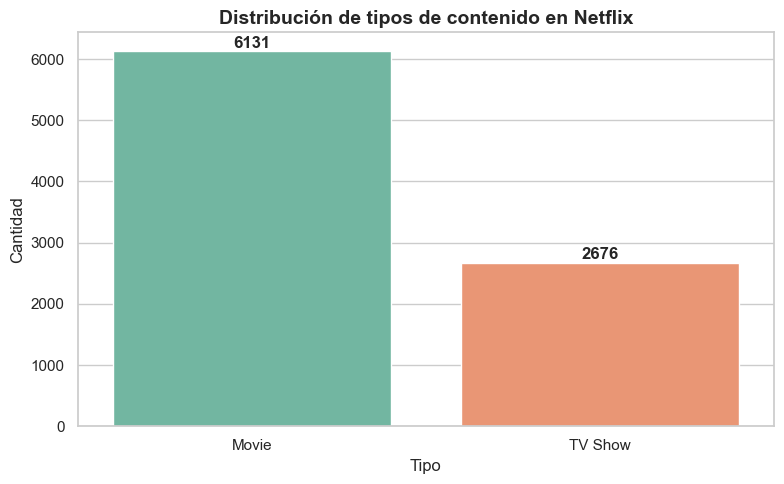


Porcentaje Movies: 69.6%
Porcentaje TV Shows: 30.4%


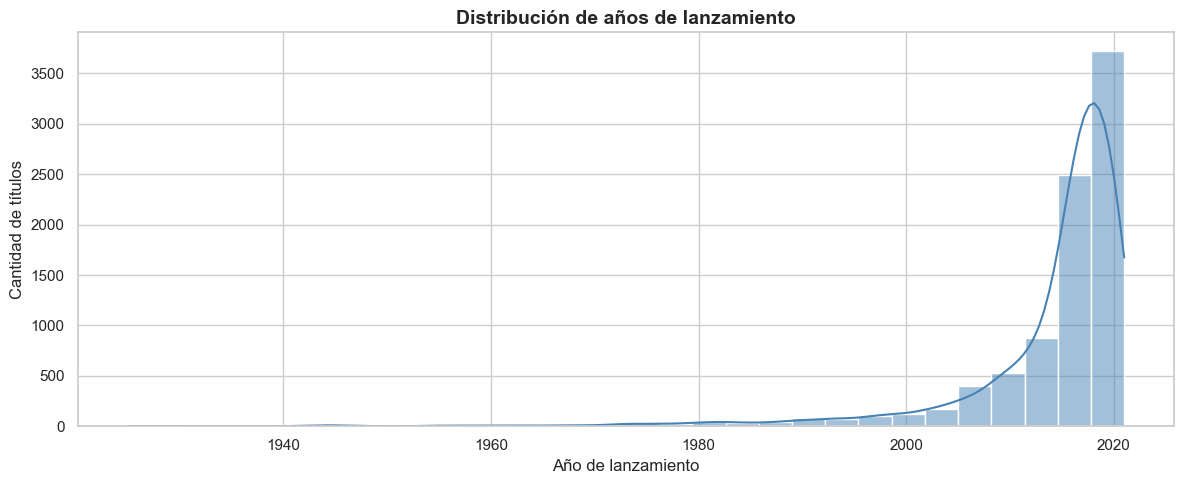

/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49504/1395792794.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis', ax=ax)


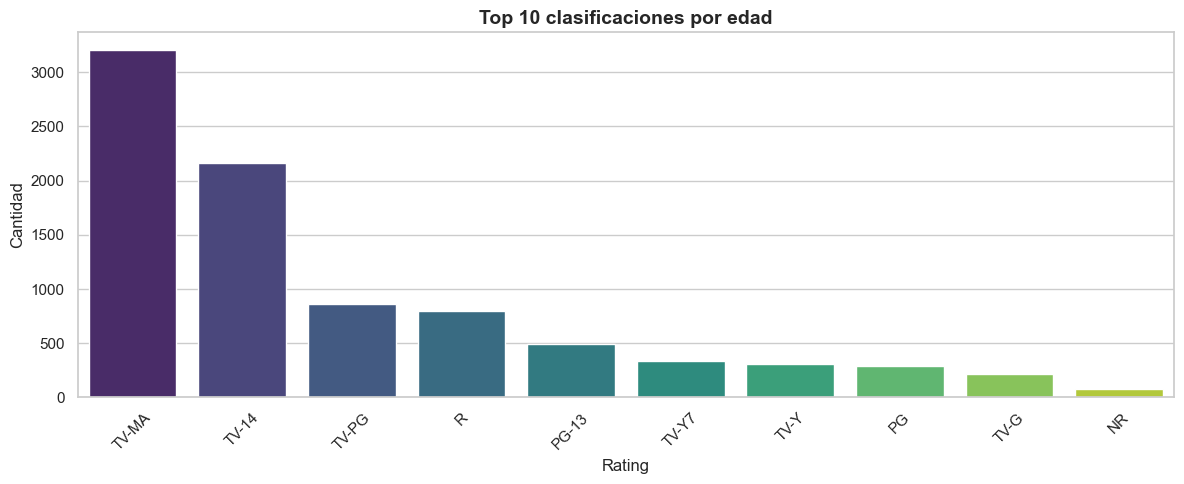

In [3]:
# Parte 1: Exploración visual básica

# Preparación: fechas y columnas auxiliares
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# 1. Distribución de tipos de contenido (Movie vs TV Show)
fig, ax = plt.subplots(figsize=(8, 5))
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2', ax=ax)
ax.set_title('Distribución de tipos de contenido en Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo')
ax.set_ylabel('Cantidad')
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nPorcentaje Movies: {type_counts['Movie'] / type_counts.sum() * 100:.1f}%")
print(f"Porcentaje TV Shows: {type_counts['TV Show'] / type_counts.sum() * 100:.1f}%")

# 2. Histograma de años de lanzamiento
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['release_year'], bins=30, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribución de años de lanzamiento', fontsize=14, fontweight='bold')
ax.set_xlabel('Año de lanzamiento')
ax.set_ylabel('Cantidad de títulos')
plt.tight_layout()
plt.show()

# 3. Proporción de clasificaciones por edad (rating)
fig, ax = plt.subplots(figsize=(12, 5))
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis', ax=ax)
ax.set_title('Top 10 clasificaciones por edad', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 🎨 Parte 2: Tendencias y evolución en el tiempo

4. **Número de títulos agregados por año**

   * Usa `date_added` (convertido a fecha) y grafica una serie temporal.
   * Pregunta guía: ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?

5. **Heatmap de lanzamientos por año y mes**

   * Construye un mapa de calor con `year_added` y `month_added`.
   * Pregunta guía: ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?

6. **Duración de películas por género**

   * Extrae la duración en minutos y crea un boxplot agrupado por género principal.
   * Pregunta guía: ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?


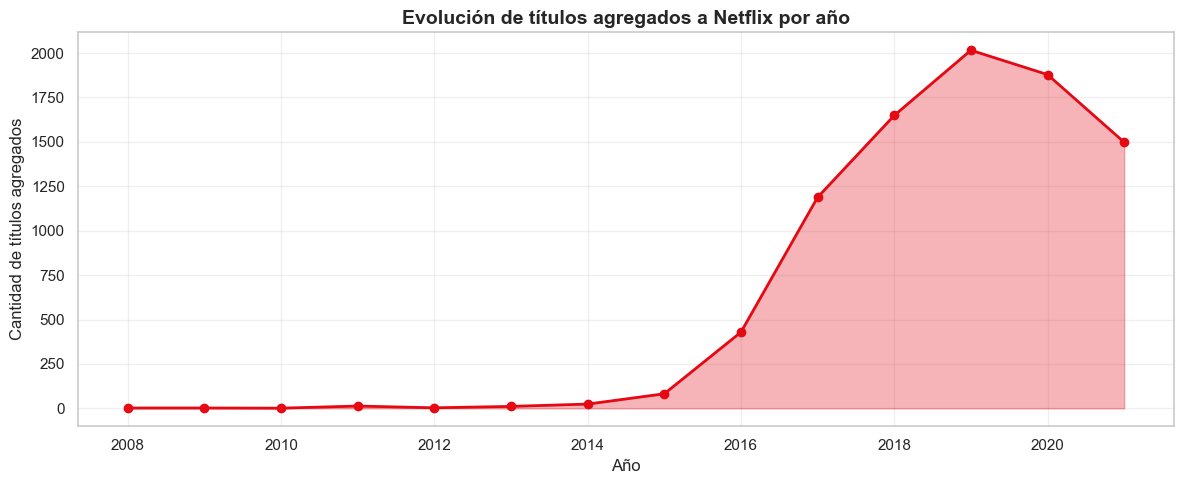

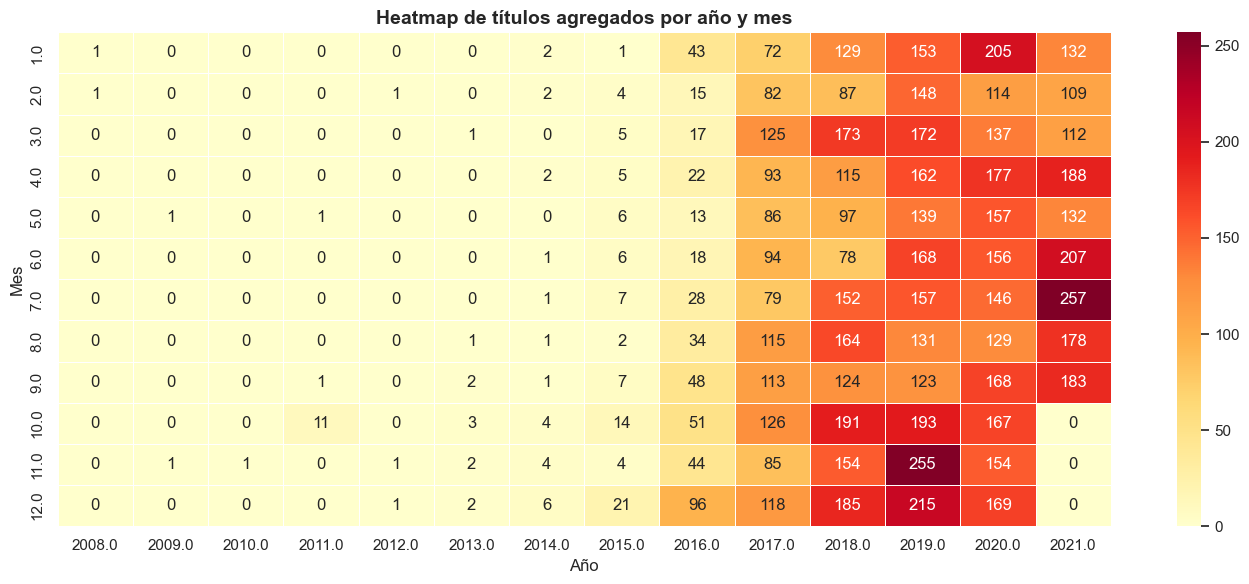

/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49504/561975809.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='primary_genre', y='duration_min', palette='Set3', ax=ax)


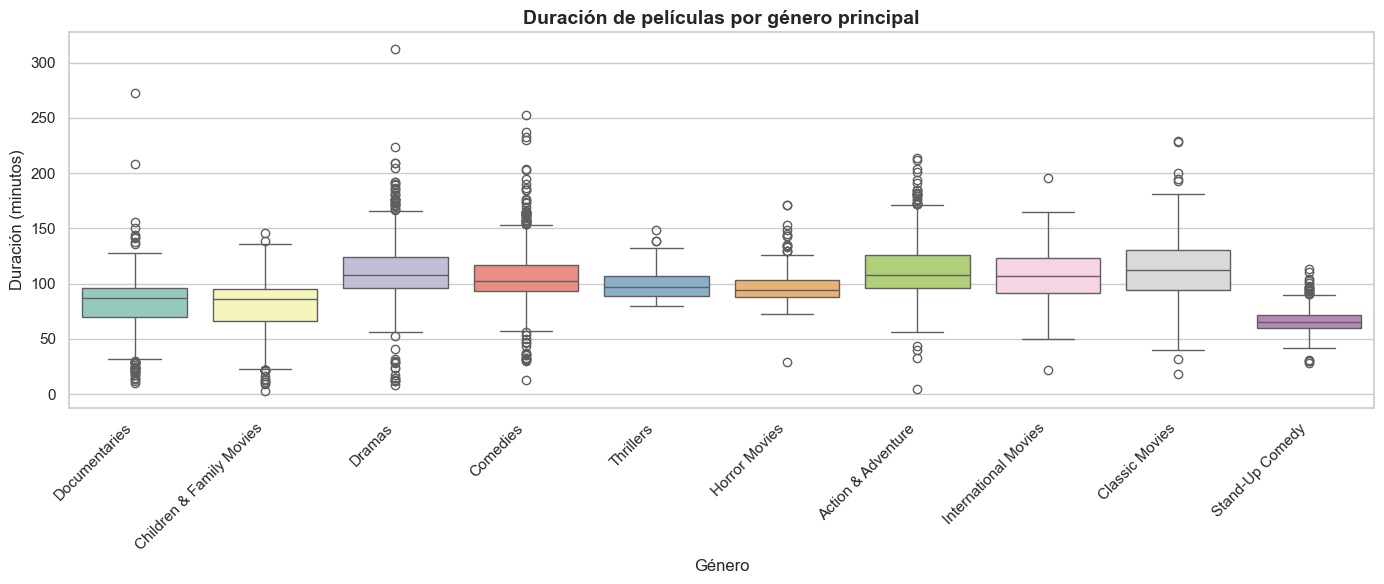

In [4]:
# Parte 2: Tendencias y evolución en el tiempo

# 4. Número de títulos agregados por año
fig, ax = plt.subplots(figsize=(12, 5))
titulos_por_anio = df.groupby('year_added').size()
ax.plot(titulos_por_anio.index, titulos_por_anio.values, marker='o', linewidth=2, color='#E50914')
ax.fill_between(titulos_por_anio.index, titulos_por_anio.values, alpha=0.3, color='#E50914')
ax.set_title('Evolución de títulos agregados a Netflix por año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de títulos agregados')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Heatmap de lanzamientos por año y mes
df_heatmap = df.dropna(subset=['year_added', 'month_added'])
pivot_heatmap = df_heatmap.pivot_table(
    index='month_added',
    columns='year_added',
    values='show_id',
    aggfunc='count',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_heatmap, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, ax=ax)
ax.set_title('Heatmap de títulos agregados por año y mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Mes')
plt.tight_layout()
plt.show()

# 6. Duración de películas por género (boxplot)
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)').astype(float)
df_movies['primary_genre'] = df_movies['listed_in'].str.split(', ').str[0]

top_genres = df_movies['primary_genre'].value_counts().head(10).index
df_top = df_movies[df_movies['primary_genre'].isin(top_genres)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_top, x='primary_genre', y='duration_min', palette='Set3', ax=ax)
ax.set_title('Duración de películas por género principal', fontsize=14, fontweight='bold')
ax.set_xlabel('Género')
ax.set_ylabel('Duración (minutos)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



## 🔥 Parte 3: Comparaciones y relaciones

7. **Top 10 países con más producciones**

   * Usa un gráfico de barras para mostrar los países más frecuentes en la columna `country`.
   * Pregunta guía: ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?

8. **Películas vs Series según género**

   * Realiza un gráfico de barras apiladas para mostrar la cantidad de títulos por género, separando `Movie` y `TV Show`.
   * Pregunta guía: ¿Existen géneros más asociados a películas o a series?

9. **Relación entre duración y año de lanzamiento**

   * Haz un gráfico de dispersión (scatterplot) con `release_year` en el eje X y `duration` (en minutos) en el eje Y.
   * Pregunta guía: ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?



/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49504/2195379934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, palette='rocket', ax=ax)


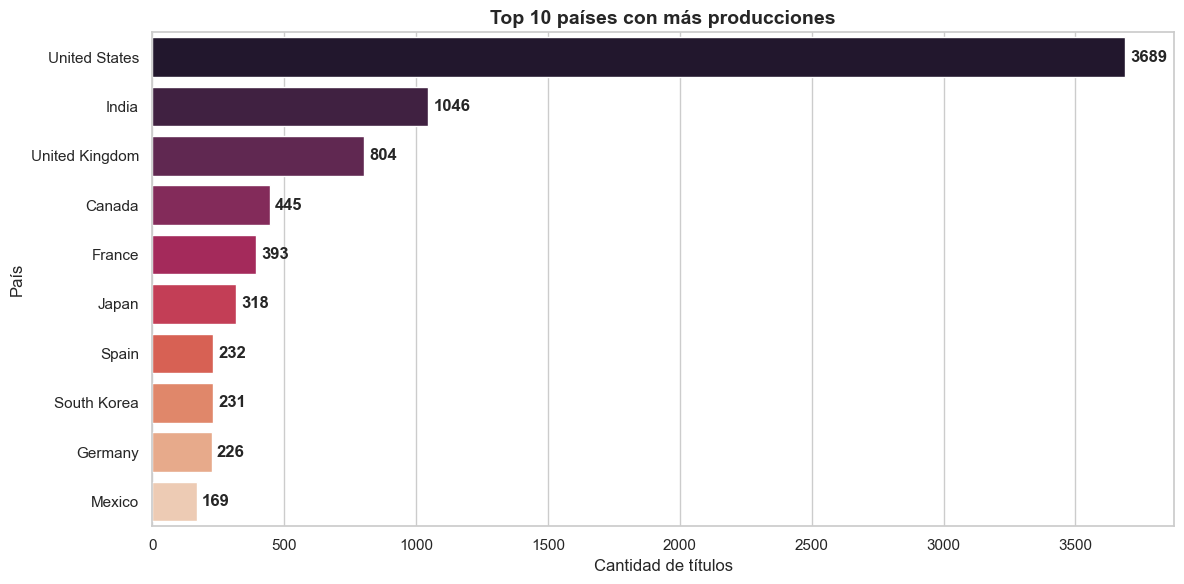

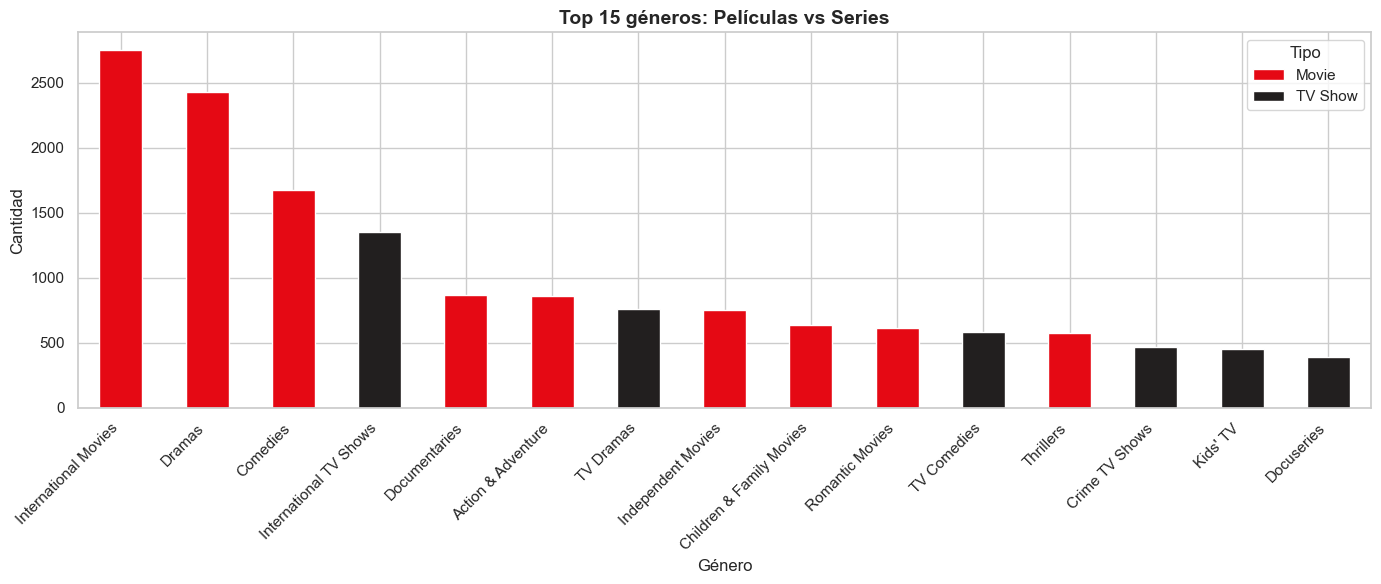

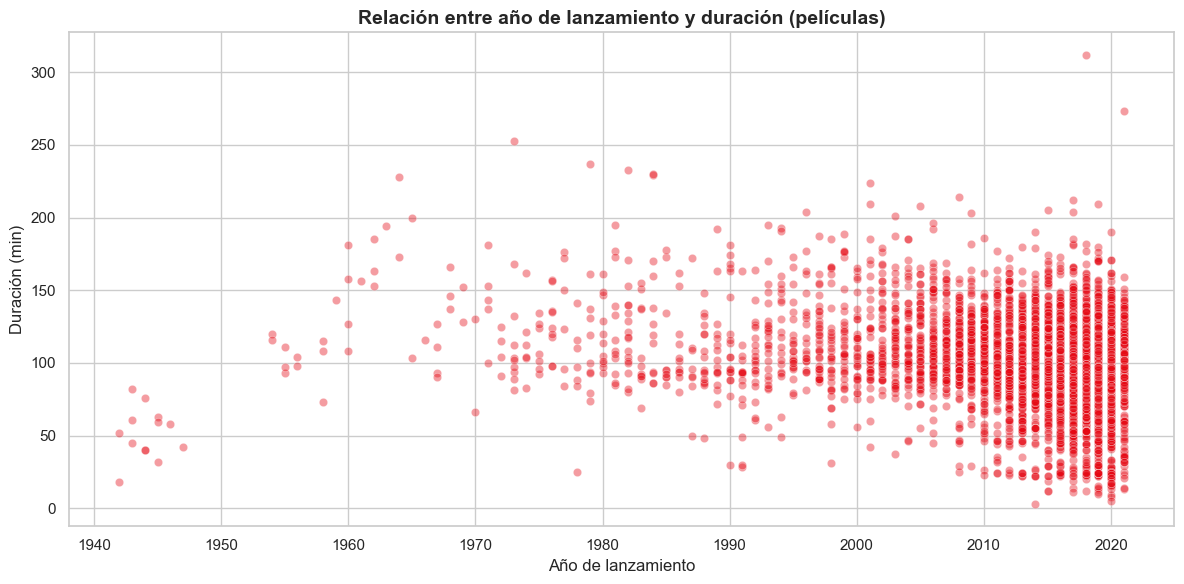

In [5]:
# Parte 3: Comparaciones y relaciones

# 7. Top 10 países con más producciones
df_country = df.dropna(subset=['country']).copy()
df_country = df_country.assign(country=df_country['country'].str.split(', ')).explode('country')
top_paises = df_country['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_paises.values, y=top_paises.index, palette='rocket', ax=ax)
ax.set_title('Top 10 países con más producciones', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de títulos')
ax.set_ylabel('País')
for i, v in enumerate(top_paises.values):
    ax.text(v + 20, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 8. Películas vs Series por género (barras apiladas)
df_genre = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
genre_type = df_genre.groupby(['genre', 'type']).size().unstack(fill_value=0)
top_15_generos = genre_type.sum(axis=1).nlargest(15).index
genre_type_top = genre_type.loc[top_15_generos]

fig, ax = plt.subplots(figsize=(14, 6))
genre_type_top.plot(kind='bar', stacked=True, ax=ax, color=['#E50914', '#221F1F'])
ax.set_title('Top 15 géneros: Películas vs Series', fontsize=14, fontweight='bold')
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

# 9. Relación entre duración y año de lanzamiento (scatter)
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)').astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_movies, x='release_year', y='duration_min', alpha=0.4, color='#E50914', ax=ax)
ax.set_title('Relación entre año de lanzamiento y duración (películas)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año de lanzamiento')
ax.set_ylabel('Duración (min)')
plt.tight_layout()
plt.show()

## ⭐ Desafío Final

* Encuentra las combinaciones más frecuentes de **género + rating** y represéntalas en un **heatmap o gráfico de burbujas**.
* Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?

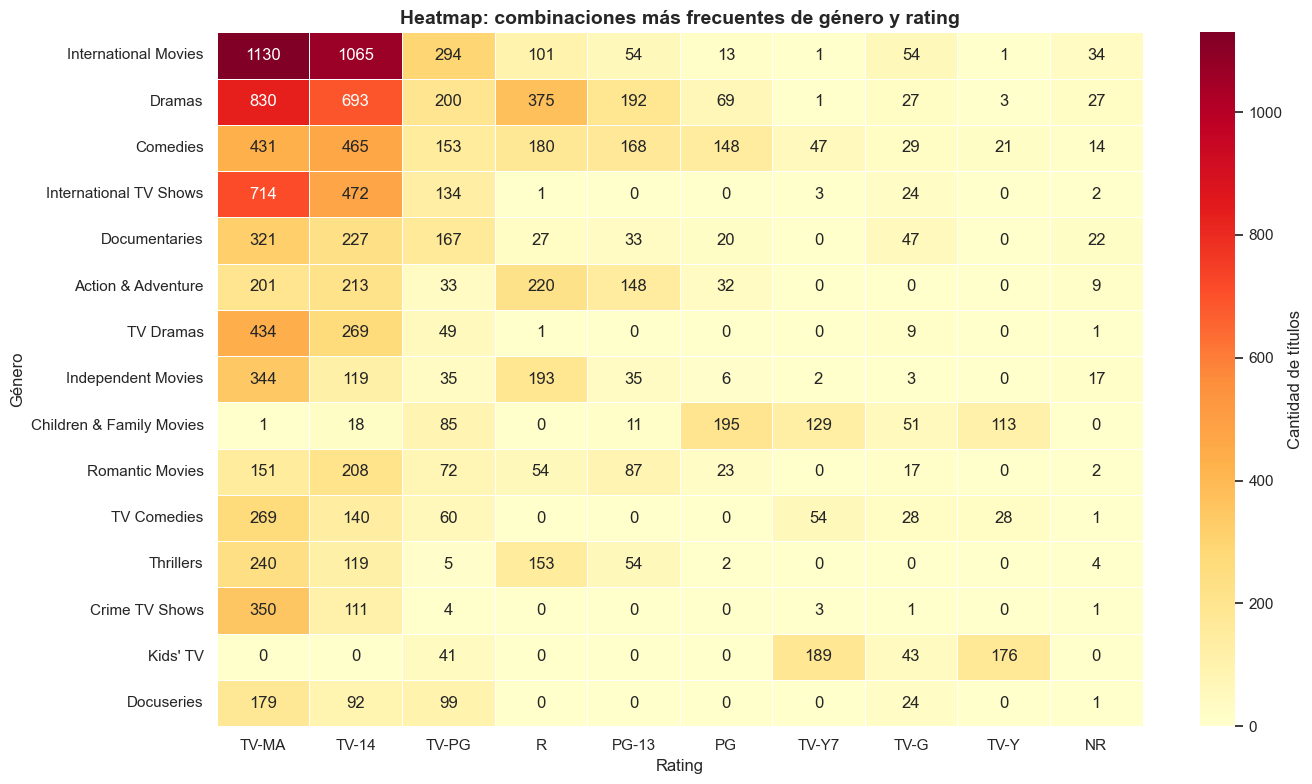


Conclusiones:
- Los géneros 'International Movies' y 'Dramas' dominan en rating TV-MA → orientado a adultos.
- 'Children & Family Movies' y 'Kids' TV aparecen con TV-Y, TV-Y7, TV-G → contenido familiar/infantil.
- La mayoría del catálogo de Netflix se inclina hacia audiencia adulta (TV-MA, R).


In [6]:
# Desafío Final: Heatmap de género + rating

df_combinaciones = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
combo = df_combinaciones.groupby(['genre', 'rating']).size().unstack(fill_value=0)

# Filtrar los 15 géneros y 10 ratings más frecuentes
top_generos = combo.sum(axis=1).nlargest(15).index
top_ratings = combo.sum(axis=0).nlargest(10).index
combo_top = combo.loc[top_generos, top_ratings]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(combo_top, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5,
            cbar_kws={'label': 'Cantidad de títulos'}, ax=ax)
ax.set_title('Heatmap: combinaciones más frecuentes de género y rating',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Género')
plt.tight_layout()
plt.show()

print("\nConclusiones:")
print("- Los géneros 'International Movies' y 'Dramas' dominan en rating TV-MA → orientado a adultos.")
print("- 'Children & Family Movies' y 'Kids' TV aparecen con TV-Y, TV-Y7, TV-G → contenido familiar/infantil.")
print("- La mayoría del catálogo de Netflix se inclina hacia audiencia adulta (TV-MA, R).")